# **RUN THIS NOTEBOOK AFTER EXTRACTING JSONS TO `data/extracted_sections`**

# **Step 1 - Configuration and Imports**

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR  = "../data/extracted_sections"
CLEAN_PATH  = "../data/ESG_data_cleaned.csv"
FINAL_PATH  = "../data/extraction_final.csv"

THRESHOLDS = {
    'business_chars':  500_000,
    'risk_chars':      850_000,
    'mda_chars':       700_000
}

print("Config loaded.")

Config loaded.


# **Step 2 - Helper Functions**

In [2]:
def load_audit_df(output_dir=OUTPUT_DIR):
    """Build audit dataframe from all extracted JSON files."""
    records = []
    for fname in os.listdir(output_dir):
        if not fname.endswith(".json"):
            continue
        with open(os.path.join(output_dir, fname)) as f:
            data = json.load(f)
        s = data['sections']
        records.append({
            'ticker':         data['ticker'],
            'business_chars': len(s['business'])     if s['business']     else 0,
            'risk_chars':     len(s['risk_factors'])  if s['risk_factors'] else 0,
            'mda_chars':      len(s['mda'])           if s['mda']          else 0,
            'sections_found': sum(v is not None for v in s.values())
        })
    df = pd.DataFrame(records).sort_values('ticker').reset_index(drop=True)
    print(f"Loaded {len(df)} extracted companies.")
    return df


def flag_runaways(df, thresholds=THRESHOLDS):
    """Flag companies with section sizes exceeding 10x median thresholds."""
    df = df.copy()
    df['runaway'] = (
        (df['business_chars'] > thresholds['business_chars']) |
        (df['risk_chars']     > thresholds['risk_chars'])     |
        (df['mda_chars']      > thresholds['mda_chars'])
    )
    runaways = df[df['runaway']].copy()
    print(f"Runaway extractions flagged: {len(runaways)}")
    return df, runaways


def show_partials(df):
    """Return companies with fewer than 3 sections extracted."""
    partials = df[df['sections_found'] < 3].copy()
    print(f"Partial extractions: {len(partials)}")
    return partials


def plot_distributions(df):
    """Plot section size distributions with runaway threshold lines."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    cols   = ['business_chars', 'risk_chars', 'mda_chars']
    labels = ['Business', 'Risk Factors', 'MD&A']

    for ax, col, label in zip(axes, cols, labels):
        data = df[col][df[col] > 0]
        sns.histplot(data, bins=50, ax=ax, color='steelblue', edgecolor='white')
        ax.axvline(THRESHOLDS[col], color='red', linestyle='--', label=f'Threshold ({THRESHOLDS[col]:,})')
        ax.set_title(f'{label} Section Size')
        ax.set_xlabel('Characters')
        ax.set_ylabel('Count')
        ax.legend()

    plt.suptitle('Section Size Distributions with Runaway Thresholds', y=1.02)
    plt.tight_layout()
    plt.show()


def export_final(df, runaways, path=FINAL_PATH):
    """
    Export cleaned extraction list, excluding runaway extractions.
    Merges with ESG data to confirm coverage.
    """
    esg_df  = pd.read_csv(CLEAN_PATH)
    esg_df['ticker'] = esg_df['ticker'].str.upper()

    clean_df = df[~df['runaway'] & (df['sections_found'] == 3)][['ticker', 'sections_found', 'business_chars', 'risk_chars', 'mda_chars']]
    final_df = esg_df.merge(clean_df, on='ticker', how='inner')
    final_df.to_csv(path, index=False)

    print(f"Final cleaned dataset: {len(final_df)} companies")
    print(f"Excluded (runaway or partial): {len(df) - len(final_df)}")
    print(f"Saved to {path}")
    return final_df

print("Helper functions loaded.")

Helper functions loaded.


# **Step 3 - Load Extractions and Summarise**

In [3]:
audit_df = load_audit_df()

print("\n=== Coverage ===")
for n in [3, 2, 1, 0]:
    print(f"  {n}/3 sections: {(audit_df['sections_found'] == n).sum()} companies")

print("\n=== Section Size Summary (characters) ===")
for col, label in [('business_chars','BUSINESS'),('risk_chars','RISK FACTORS'),('mda_chars','MD&A')]:
    s = audit_df[col][audit_df[col] > 0]
    print(f"\n{label}")
    print(f"  Mean:   {s.mean():>12,.0f}")
    print(f"  Median: {s.median():>12,.0f}")
    print(f"  Min:    {s.min():>12,.0f}")
    print(f"  Max:    {s.max():>12,.0f}")

Loaded 640 extracted companies.

=== Coverage ===
  3/3 sections: 618 companies
  2/3 sections: 17 companies
  1/3 sections: 5 companies
  0/3 sections: 0 companies

=== Section Size Summary (characters) ===

BUSINESS
  Mean:        604,613
  Median:       47,326
  Min:             200
  Max:      32,160,939

RISK FACTORS
  Mean:      1,212,059
  Median:       84,111
  Min:             101
  Max:      74,141,257

MD&A
  Mean:        779,739
  Median:       69,358
  Min:             100
  Max:      74,160,319


# **Step 4 - Inspect Suspect Tickers**

In [4]:
def inspect_ticker(ticker, output_dir=OUTPUT_DIR, chars=500):
    """Print the start and end of each extracted section for a given ticker."""
    path = os.path.join(output_dir, f"{ticker}.json")
    if not os.path.exists(path):
        print(f"{ticker}: no JSON found.")
        return
    with open(path) as f:
        data = json.load(f)
    sections = data['sections']
    print(f"\n{'='*60}")
    print(f"TICKER: {ticker}")
    print(f"{'='*60}")
    for name, text in sections.items():
        print(f"\n--- {name.upper()} ---")
        if text:
            print(f"Length: {len(text):,} chars")
            print(f"START:\n{text[:chars]}")
            print(f"\nEND:\n{text[-chars:]}")
        else:
            print("NOT FOUND")


inspect_ticker("CLX")


TICKER: CLX

--- BUSINESS ---
Length: 5,832,090 chars
START:
ITEM 1. BUSINESSOverview of BusinessThe Clorox Company is a leading multinational manufacturer and marketer of consumer and professional products with fiscal year 2021 net sales of $7.3 billion and about 9,000 employees worldwide as of June 30, 2021. Its products are sold primarily through mass retailers; grocery outlets; warehouse clubs; dollar stores; home hardware centers; drug, pet and military stores; third-party and owned e-commerce channels; and distributors. Clorox markets some of the mo

END:
 Z:PT M% @ &.G < 8VQX+3(P,C$P-C,P7W!R92YX;6Q02P$"% ,4 M " #F@0I3&*&3 _D* #?\0 #P @ %ZN@@ 9GDR,6-L M>&5X,C$N:'1M4$L! A0#% @ YH$*4X)!^:/2 P = T \ M ( !H,4( &9Y,C%C;'AE>#(S+FAT;5!+ 0(4 Q0 ( .:!"E/AI]YE MNP< "(F 0 " 9_)" !F>3(Q8VQX97@S,3$N:'1M4$L! M A0#% @ YH$*4XNH[XBY!P GB4 ! ( !B-$( &9Y M,C%C;'AE>#,Q,BYH=&U02P$"% ,4 " #F@0I3I Y3J_X$ O& #P M @ %OV0@ 9GDR,6-L>&5X,S(N:'1M4$L! A0#% @ YH$* M4WU1D_\_#@ MM\ !, ( !FMX( &9Y,C%C;'AE>#DY,C$

# **Step 5 - Flag Runaways/Regex Errors**

In [5]:
audit_df, runaways = flag_runaways(audit_df)

print("\n=== Runaway Extractions ===")
print(runaways[['ticker', 'sections_found', 'business_chars', 'risk_chars', 'mda_chars']].to_string(index=False))

Runaway extractions flagged: 60

=== Runaway Extractions ===
ticker  sections_found  business_chars  risk_chars  mda_chars
  ACHV               3           95799     4420797      60030
  ACMR               3           38202     8840399     291797
  ACNB               3         6992406     6992390    6992108
   AEY               2         2593723           0    2571562
   AIG               3          133705    74141257   74160319
  AKRO               3          174559     6855181      46122
  AKTS               3         6073926      110283      22240
   AOS               3         8851013     8850996    8850707
   BXP               3           74677      103308   20143469
  CHTR               3           46655    10406435      57850
  CLST               3          112698     4720831      50894
   CLX               2         5832090           0    5710578
  COST               3         5561341     5561325    5561051
   CRL               3        12001142       95993      72570
  DELL   

In [7]:
inspect_ticker("ACNB")


TICKER: ACNB

--- BUSINESS ---
Length: 6,992,406 chars
START:
Item 1.Business5Item 1A.Risk Factors14Item 1B.Unresolved Staff Comments27Item 2.Properties27Item 3.Legal Proceedings27Item 4.Mine Safety Disclosures27Part II Item 5.Market for the Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities28Item 6.[RESERVED]29Item 7.Management’s Discussion and Analysis of Financial Condition and Results of Operations30Item 7A.Quantitative and Qualitative Disclosures About Market Risk54Item 8.Financial Statements and Suppleme

END:
"% ,4 M " "AA6Y4J4\FNBC*!0 !O4@ $0 @ 'F.@ 86-N8BTR M,#(Q,3(S,2YH=&U02P$"% ,4 " "AA6Y4V"/RW\P? )4P$ $0 M @ $]!08 86-N8BTR,#(Q,3(S,2YX<V102P$"% ,4 " "AA6Y4 M(,[6)1-" #YQ0( %0 @ $X)08 86-N8BTR,#(Q,3(S,5]C M86PN>&UL4$L! A0#% @ H85N5.1\O KBM0 L$ ( !4 M ( !?F<& &%C;F(M,C R,3$R,S%?9&5F+GAM;%!+ 0(4 Q0 ( *&%;E2( MER]'[-P! -GE$@ 5 " 9,=!P!A8VYB+3(P,C$Q,C,Q7VQA M8BYX;6Q02P$"% ,4 " "AA6Y4)I'7,A06 0#=_@P %0 M@ &R^@@ 86-N8BTR,#(Q,3(S,5]P<F4

In [8]:
inspect_ticker("AIG")


TICKER: AIG

--- BUSINESS ---
Length: 133,705 chars
START:
Item 1. Business – Regulation, and Part II, Item 7. MD&A – Critical Accounting Estimates – Liabilities for Guaranteed Benefit Features of Variable Annuity, Fixed Annuity and Fixed Index Annuity Products.Reinsurance may be unavailable or too expensive relative to its benefit, and may not be adequate to protect us against losses. Our subsidiaries are major purchasers of third-party reinsurance and we use reinsurance as part of our overall risk management strategy. Our reinsurance business also pur

END:
 by consequence of hostilities and unrest. The risks of such occurrences and their overall effect upon us vary from country to country and cannot be predicted. If expropriation or nationalization does occur, our policy is to take all appropriate measures to seek recovery of any affected assets. Certain of the countries in which our business is conducted have currency restrictions that generally cause a delay in a company’s abilit

In [9]:
inspect_ticker("PSX")


TICKER: PSX

--- BUSINESS ---
NOT FOUND

--- RISK_FACTORS ---
Length: 13,941,820 chars
START:
Item 1A. Risk Factors” in this report. 78Table of ContentsIndex to Financial StatementsItem 8. FINANCIAL STATEMENTS AND SUPPLEMENTARY DATAPHILLIPS 66INDEX TO FINANCIAL STATEMENTS PageReport of Management80Reports of Independent Registered Public Accounting Firm (PCAOB ID: 42)81Consolidated Financial Statements of Phillips 66:Consolidated Statement of Operations for the years ended December 31, 2021, 2020 and 201984Consolidated Statement of Comprehensive Income (Loss) for the years ended December

END:
% ,4 M " #S@5)4;K1'?/@' #I)0 %@ @ $PI@< <'-X+3(P M,C$Q,C,Q7V5X,S$Q+FAT;5!+ 0(4 Q0 ( /.!4E01TEE8 P@ *DF 6 M " 5RN!P!P<W@M,C R,3$R,S%?97@S,3(N:'1M4$L! A0# M% @ \X%25%!]W?L/!0 ,Q8 !4 ( !D[8' '!S>"TR M,#(Q,3(S,5]E>#,R+FAT;5!+ 0(4 Q0 ( /.!4E0KY@6K9J8! 0& @ 3 M " =6[!P!P<W@M,C R,3$R,S%?9S$N:G!G4$L! A0#% M @ \X%25&8IGT5/*@( $EP6 !0 ( !;&() '!S>"TR,#(Q M,3(S,5]L86(N>&UL4$L! A0#% @ \X%25"1LTO_9;@$ E%L1 !

# **Step 6 - Partial Extractions Inspection**

In [ ]:
partials = show_partials(audit_df)
print(partials[['ticker', 'sections_found', 'business_chars', 'risk_chars', 'mda_chars']].to_string(index=False))

# **Step 7 - Vizualizations**

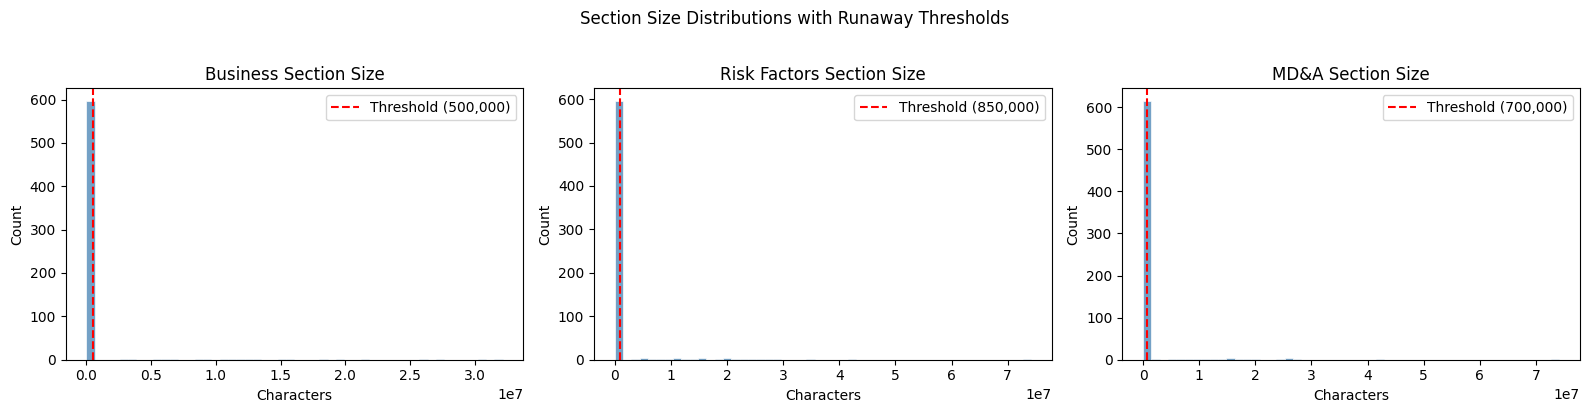

In [6]:
plot_distributions(audit_df)

# **Step 8 - Export Final Dataset for FinBERT**

In [ ]:
final_df = export_final(audit_df, runaways)
final_df.head()